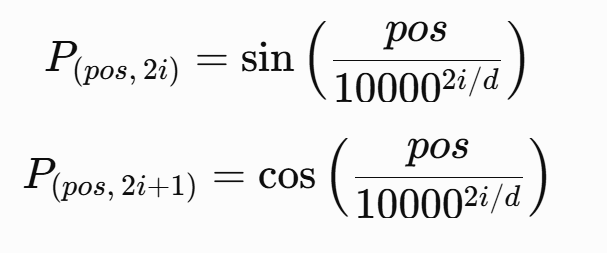

In [1]:
# self attention
# 加入位置信息
import math
import torch
from torch import nn
from d2l import torch as d2l


class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()

        self.dropout = nn.Dropout(dropout)

        # P.shape = (1, max_len, num_hiddens)
        self.P = torch.zeros((1, max_len, num_hiddens))

        X = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1) / torch.pow(
            10000, torch.arange(0, num_hiddens, 2, dtype=torch.float32) / num_hiddens
        )

        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, : X.shape[1], :].to(X.device)
        return self.dropout(X)

In [2]:
import torch
from torch import nn
from d2l import torch as d2l


def transpose_qkv(X, num_heads):
    """
    为多头注意力变换 Q、K、V 的形状

    输入:
        X.shape = (batch_size, num_steps, num_hiddens)

    输出:
        (batch_size * num_heads,
         num_steps,
         num_hiddens / num_heads)
    """

    # (b, n, d)
    # ->
    # (b, n, h, d/h)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # (b, n, h, d/h)
    # ->
    # (b, h, n, d/h)
    X = X.permute(0, 2, 1, 3)

    # (b, h, n, d/h)
    # ->
    # (b*h, n, d/h)
    return X.reshape(-1, X.shape[2], X.shape[3])


def transpose_output(X, num_heads):
    """
    逆转 transpose_qkv 的操作

    输入:
        X.shape =
        (batch_size * num_heads,
         num_steps,
         num_hiddens / num_heads)

    输出:
        (batch_size, num_steps, num_hiddens)
    """

    # (b*h, n, d/h)
    # ->
    # (b, h, n, d/h)
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])

    # (b, h, n, d/h)
    # ->
    # (b, n, h, d/h)
    X = X.permute(0, 2, 1, 3)

    # (b, n, h, d/h)
    # ->
    # (b, n, d)
    return X.reshape(X.shape[0], X.shape[1], -1)


class MultiHeadAttention(nn.Module):
    """多头注意力"""

    # 目的：让模型可以学习多种不同的当前单词和其它单词的关系，产生多套score,并以此达到更好的训练效果
    def __init__(
        self,
        query_size,
        key_size,
        value_size,
        num_hiddens,
        num_heads,
        dropout,
        bias=False,
    ):
        super().__init__()

        self.num_heads = num_heads

        # 每一个 head 最终使用的就是缩放点积注意力
        self.attention = d2l.DotProductAttention(dropout)

        # Q、K、V 的可训练线性映射
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)

        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)

        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)

        # 多个 head 拼接以后再做一次线性映射
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # --------------------------------
        # 1. 线性映射 + 拆成多个 head
        # --------------------------------

        queries = transpose_qkv(self.W_q(queries), self.num_heads)

        keys = transpose_qkv(self.W_k(keys), self.num_heads)

        values = transpose_qkv(self.W_v(values), self.num_heads)

        # 此时：
        #
        # queries:
        # (batch*num_heads, num_queries, d_head)
        #
        # keys:
        # (batch*num_heads, num_keys, d_head)
        #
        # values:
        # (batch*num_heads, num_keys, d_head)

        # --------------------------------
        # 2. 每个 head 都需要自己的 valid_len
        # --------------------------------

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0
            )

        # --------------------------------
        # 3. 每个 head 独立做缩放点积注意力
        # --------------------------------

        output = self.attention(queries, keys, values, valid_lens)

        # output.shape:
        #
        # (batch*num_heads,
        #  num_queries,
        #  d_head)

        # --------------------------------
        # 4. 把多个 head 拼回来
        # --------------------------------

        output_concat = transpose_output(output, self.num_heads)

        # output_concat.shape:
        #
        # (batch,
        #  num_queries,
        #  num_hiddens)

        # --------------------------------
        # 5. 最后一层输出投影
        # --------------------------------

        return self.W_o(output_concat)

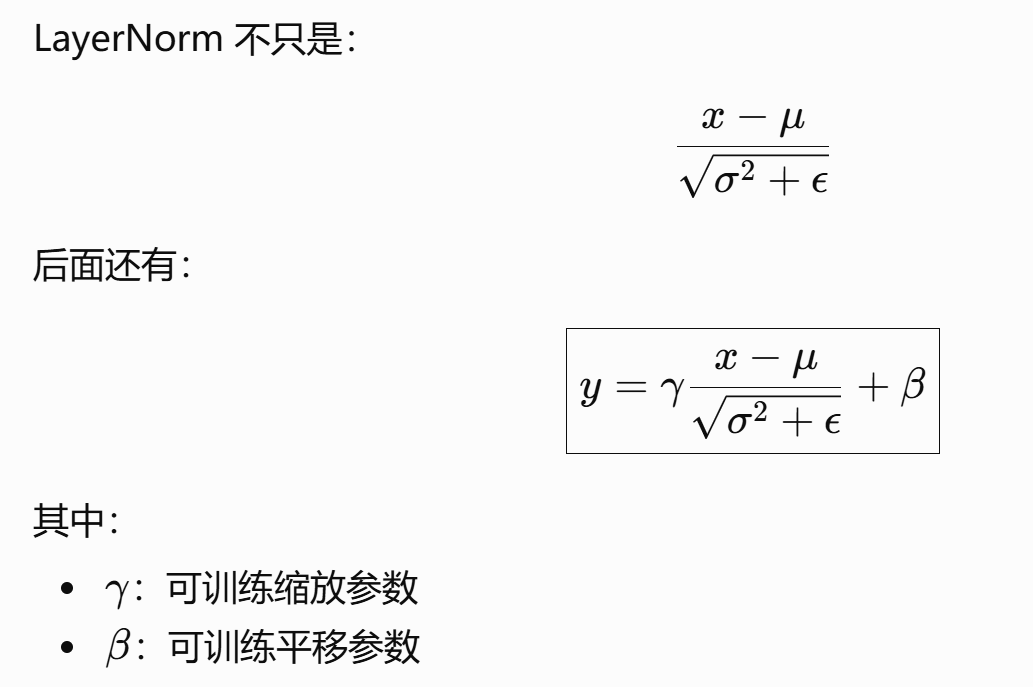

In [ ]:
import math
import torch
from torch import nn
from d2l import torch as d2l

# ============================================================
# 1. Position-wise Feed Forward Network
# ============================================================


class PositionWiseFFN(nn.Module):
    def __init__(self, ffn_num_hiddens: int, ffn_num_outputs: int):
        super().__init__()

        # 第一个全连接层：d -> ffn_hidden
        # LazyLinear 会自动推断输入的最后一维
        self.dense1 = nn.LazyLinear(ffn_num_hiddens)

        self.relu = nn.ReLU()

        # 第二个全连接层：ffn_hidden -> d
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))


# ============================================================
# 2. Add & Norm
# ============================================================


class AddNorm(nn.Module):
    def __init__(self, normalized_shape, dropout: float):
        super().__init__()

        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)  # 有训练参数

    def forward(self, X, Y):
        # 只对Y做dropout的原因
        # X是前面已经得到的结果，加上它是为了给后面保留信息，所以不能再丢信息了，Y是刚训练出来的结果，可以随机丢弃一部分，起正则化作用
        return self.ln(X + self.dropout(Y))


# ============================================================
# 3. Transformer Encoder Block
# ============================================================


# 训练其中的参数使得它能够提取出更有用的上下文信息，自注意力机制使最终的每个token包含上下文信息
class EncoderBlock(nn.Module):
    def __init__(
        self,
        num_hiddens: int,
        ffn_num_hiddens: int,
        num_heads: int,
        dropout: float,
        use_bias: bool = False,
    ):
        super().__init__()

        # Self-Attention
        self.attention = d2l.MultiHeadAttention(
            num_hiddens, num_heads, dropout, use_bias
        )
        # addnorm里面有训练参数，所以要设两个
        self.addnorm1 = AddNorm(num_hiddens, dropout)

        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)

        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        # self-attention:
        # Q = K = V = X
        attn_output = self.attention(X, X, X, valid_lens)

        # 第一个 Add & Norm
        Y = self.addnorm1(X, attn_output)

        # FFN + 第二个 Add & Norm
        return self.addnorm2(Y, self.ffn(Y))


# ============================================================
# 4. Transformer Encoder
# ============================================================


class TransformerEncoder(d2l.Encoder):
    def __init__(
        self,
        vocab_size: int,
        num_hiddens: int,
        ffn_num_hiddens: int,
        num_heads: int,
        num_layers: int,
        dropout: float,
        use_bias: bool = False,
    ):
        super().__init__()

        self.num_hiddens = num_hiddens

        self.embedding = nn.Embedding(vocab_size, num_hiddens)

        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)

        self.blks = nn.Sequential()

        for i in range(num_layers):
            self.blks.add_module(
                f"block{i}",
                EncoderBlock(
                    num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias
                ),
            )

    def forward(self, X, valid_lens, *args):

        # embedding 的值通常比较小
        # 乘 sqrt(d) 调整尺度，避免位置信息占比过大
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))

        # 保存 attention weights，方便后面画图
        self.attention_weights = [None] * len(self.blks)

        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)

            self.attention_weights[i] = blk.attention.attention.attention_weights

        return X


# ============================================================
# 5. Transformer Decoder Block
# ============================================================


class DecoderBlock(nn.Module):
    def __init__(
        self,
        num_hiddens: int,
        ffn_num_hiddens: int,
        num_heads: int,
        dropout: float,
        i: int,
    ):
        super().__init__()

        self.i = i

        # Decoder masked self-attention
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)

        self.addnorm1 = AddNorm(num_hiddens, dropout)

        # Encoder-Decoder cross attention
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)

        self.addnorm2 = AddNorm(num_hiddens, dropout)

        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)

        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):

        enc_outputs = state[0]
        enc_valid_lens = state[1]

        # ----------------------------------------------------
        # 预测阶段需要缓存前面已经生成的 token 表示，
        # 因为预测阶段要跑好几轮，每一轮都要跑完所有层，
        # 也就是一个层被经过很多次，所以保留每一层之前的信息，
        # 用于之后再到这一层时的信息整合
        # 训练阶段用不到这个功能，因为就跑一轮
        # ----------------------------------------------------

        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), dim=1)

        state[2][self.i] = key_values

        # ----------------------------------------------------
        # Masked Self-Attention
        # ----------------------------------------------------

        if self.training:
            batch_size, num_steps, _ = X.shape

            # 所以这里用causal mask(因果掩码),使得第t个 query 只考虑前 t 个 token
            dec_valid_lens = torch.arange(1, num_steps + 1, device=X.device).repeat(
                batch_size, 1
            )

        else:
            # 预测时这里的key_values只有前面的，没有后面的数据，所以不用做掩码
            dec_valid_lens = None

        X2 = self.attention1(
            X, key_values, key_values, dec_valid_lens
        )  # dec_valid_lens==None时内部不会做任何掩码

        Y = self.addnorm1(X, X2)

        # ----------------------------------------------------
        # Encoder-Decoder Attention
        #
        # Q = decoder hidden
        # K = V = encoder outputs
        # ----------------------------------------------------

        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)

        Z = self.addnorm2(Y, Y2)

        # FFN
        output = self.addnorm3(Z, self.ffn(Z))

        return output, state


# ============================================================
# 6. Transformer Decoder
# ============================================================


class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(
        self,
        vocab_size: int,
        num_hiddens: int,
        ffn_num_hiddens: int,
        num_heads: int,
        num_layers: int,
        dropout: float,
    ):
        super().__init__()

        self.num_hiddens = num_hiddens
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, num_hiddens)

        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)

        self.blks = nn.Sequential()

        for i in range(num_layers):
            self.blks.add_module(
                f"block{i}",
                DecoderBlock(num_hiddens, ffn_num_hiddens, num_heads, dropout, i),
            )

        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # state:
        #
        # 0: encoder outputs
        # 1: encoder valid lengths
        # 2: 每个 decoder block 的缓存
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):

        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))

        # 两类 attention：
        #
        # 0 -> decoder self-attention
        # 1 -> encoder-decoder attention
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]

        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)

            self._attention_weights[0][i] = blk.attention1.attention.attention_weights

            self._attention_weights[1][i] = blk.attention2.attention.attention_weights

        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

In [4]:
class MyEncoderDecoder(d2l.EncoderDecoder):
    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)

        return self.decoder(dec_X, dec_state)

loss 0.029, 7970.7 tokens/sec on cuda:0


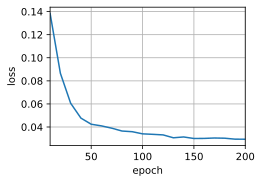

In [6]:
batch_size, num_steps = 64, 10
lr, num_epochs = 0.005, 200
device = d2l.try_gpu()

train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

num_hiddens = 32
ffn_num_hiddens = 64
num_heads = 4
num_layers = 2
dropout = 0.1

encoder = TransformerEncoder(
    len(src_vocab),
    num_hiddens,
    ffn_num_hiddens,
    num_heads,
    num_layers,
    dropout,
)

decoder = TransformerDecoder(
    len(tgt_vocab),
    num_hiddens,
    ffn_num_hiddens,
    num_heads,
    num_layers,
    dropout,
)

net = MyEncoderDecoder(encoder, decoder)

d2l.train_seq2seq(
    net,
    train_iter,
    lr,
    num_epochs,
    tgt_vocab,
    device,
)

In [7]:
engs = ["go .", "i lost .", "he's calm .", "i'm home ."]

fras = ["va !", "j'ai perdu .", "il est calme .", "je suis chez moi ."]

for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True
    )

    print(f"{eng} => {translation}, ", f"bleu {d2l.bleu(translation, fra, k=2):.3f}")

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est calme .,  bleu 1.000
i'm home . => je suis chez moi .,  bleu 1.000


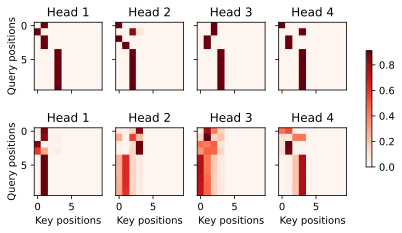

In [ ]:
enc_attention_weights = torch.cat(net.encoder.attention_weights, dim=0).reshape(
    num_layers, num_heads, -1, num_steps
)

d2l.show_heatmaps(
    enc_attention_weights.cpu(),
    xlabel="Key positions",
    ylabel="Query positions",
    titles=["Head %d" % i for i in range(1, 5)],
    figsize=(7, 3.5),
)